# 1. Imports


In [1]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

## 1.1 Kiezen cough om te replicaten

In [21]:
import shutil
import os

os.makedirs("generated/reference", exist_ok=True)

shutil.copy(
    "data/sounds/sounds/fe3424345a76c/cough_segmented/seg4_processed.wav",
    "generated/reference/reference_cough.wav"
)

print("Opgeslagen als generated/reference/reference_cough.wav")

Opgeslagen als generated/reference/reference_cough.wav


# 2. Referentie cough inladen

Duur: 2.0 seconden
Sample rate: 16000


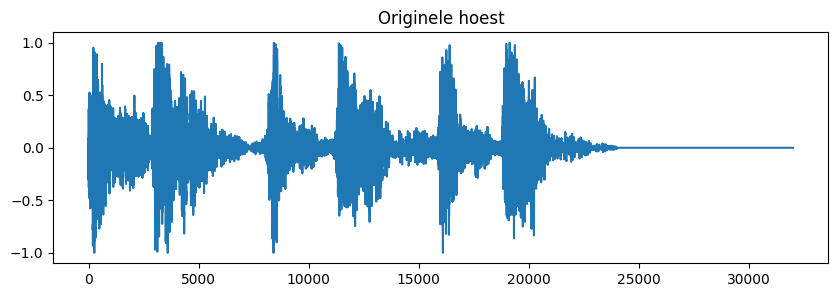

In [22]:
# dit is de hoest die we gaan reconstrueren
fp = "generated/reference/reference_cough.wav"

y, sr = librosa.load(fp, sr=16000)
print("Duur:", round(len(y)/sr, 2), "seconden")
print("Sample rate:", sr)

# even luisteren hoe het origineel klinkt
plt.figure(figsize=(10, 3))
plt.plot(y)
plt.title("Originele hoest")
plt.show()

# 3. Mel spectrogram maken van de referentie

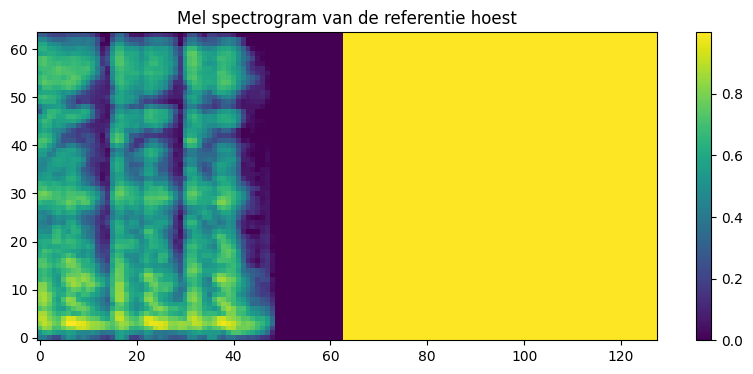

Spectrogram shape: (64, 128)


In [23]:
# mel spectrogram — dit is wat de autoencoder leert reconstrueren
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=2048, hop_length=512)
mel_db = librosa.power_to_db(mel, ref=np.max)

# vaste grootte 64 x 128
if mel_db.shape[1] < 128:
    pad = np.zeros((64, 128 - mel_db.shape[1]))
    mel_db = np.hstack([mel_db, pad])
else:
    mel_db = mel_db[:, :128]

# normaliseren naar [0, 1]
mel_min = mel_db.min()
mel_max = mel_db.max()
mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)

plt.figure(figsize=(10, 4))
plt.imshow(mel_norm, aspect='auto', origin='lower')
plt.title("Mel spectrogram van de referentie hoest")
plt.colorbar()
plt.show()

print("Spectrogram shape:", mel_norm.shape)

Dat gele is padding, die moet eigenlijk weg: 

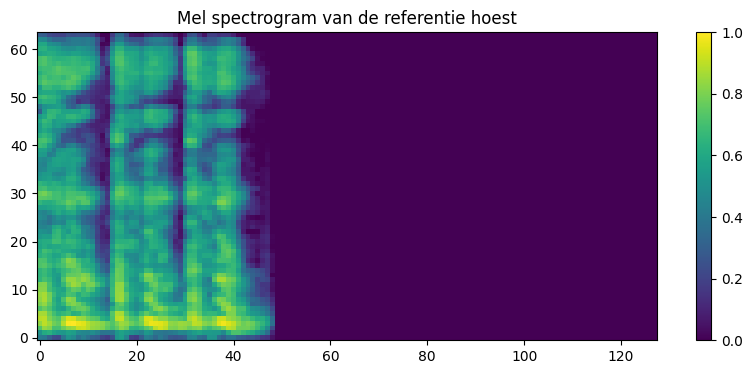

Spectrogram shape: (64, 128)


In [24]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=2048, hop_length=512)
mel_db = librosa.power_to_db(mel, ref=np.max)

# normaliseren VOOR het padden
mel_min = mel_db.min()
mel_max = mel_db.max()
mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)

# DAN pas padden — zo blijft padding gewoon 0
if mel_norm.shape[1] < 128:
    pad = np.zeros((64, 128 - mel_norm.shape[1]))
    mel_norm = np.hstack([mel_norm, pad])
else:
    mel_norm = mel_norm[:, :128]

plt.figure(figsize=(10, 4))
plt.imshow(mel_norm, aspect='auto', origin='lower')
plt.title("Mel spectrogram van de referentie hoest")
plt.colorbar()
plt.show()

print("Spectrogram shape:", mel_norm.shape)

# 4. Autoencoder bouwen

In [25]:
# --- ENCODER ---
input_img = layers.Input(shape=(64, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# --- DECODER ---
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# volledige autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 16, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 16, 8)       │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 128, 1)     │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Aparte encoder en decoder

In [26]:
# encoder apart — geeft latent space terug
encoder = Model(input_img, encoded)

# decoder apart
latent_input = layers.Input(shape=(8, 16, 8))
x = autoencoder.layers[-7](latent_input)
x = autoencoder.layers[-6](x)
x = autoencoder.layers[-5](x)
x = autoencoder.layers[-4](x)
x = autoencoder.layers[-3](x)
x = autoencoder.layers[-2](x)
decoder_output = autoencoder.layers[-1](x)

decoder = Model(latent_input, decoder_output)

print("Encoder output shape:", encoder.output_shape)
print("Decoder output shape:", decoder.output_shape)

Encoder output shape: (None, 8, 16, 8)
Decoder output shape: (None, 64, 128, 1)


# 6. Trainen op enkel onze referentie hoest

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1754
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1742
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1728
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1710
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1689
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.1663
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1633
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1596
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1553
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1501
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1442
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1381
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1308
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1221
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1135
Epoch 16/500
1/1 ━━━━

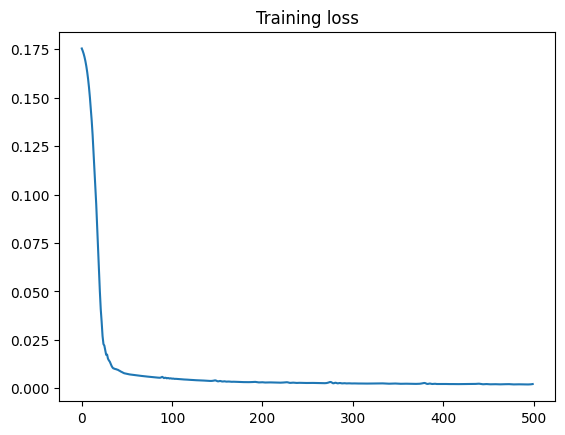

In [27]:
# input klaarmaken — shape (1, 64, 128, 1)
X_ref = mel_norm[np.newaxis, ..., np.newaxis].astype(np.float32)

autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_ref, X_ref,
    epochs=500,        # veel epochs want we hebben maar 1 sample
    batch_size=1,
    verbose=1
)

plt.plot(history.history['loss'])
plt.title('Training loss')
plt.show()

# 8. Reconstructie bekijken


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


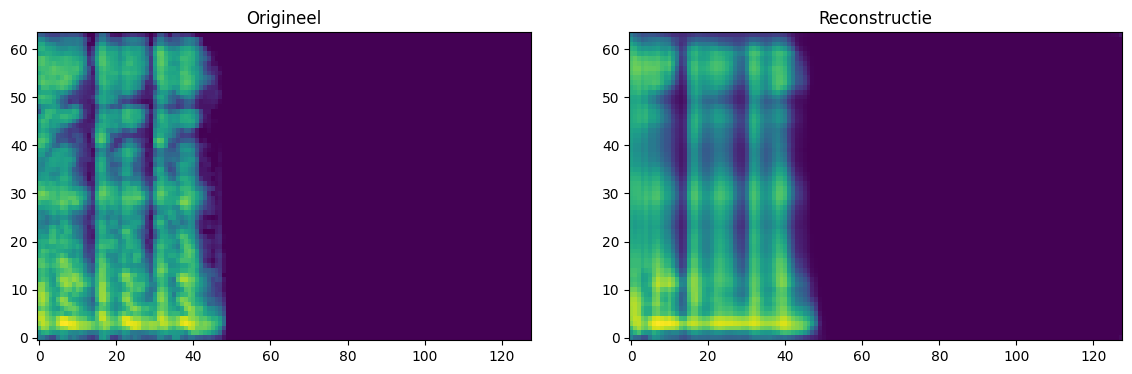

In [28]:
reconstructie = autoencoder.predict(X_ref)[0, :, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(mel_norm, aspect='auto', origin='lower')
axes[0].set_title('Origineel')
axes[1].imshow(reconstructie, aspect='auto', origin='lower')
axes[1].set_title('Reconstructie')
plt.show()

# 9. Naar wav omzetten en opslaan

In [31]:
# STAP 1 — originele STFT berekenen voor fase info
D_orig = librosa.stft(y, n_fft=2048, hop_length=512)
fase_orig = np.angle(D_orig)  # originele fases bijhouden

# STAP 2 — reconstructie mel terug naar power
mel_power = librosa.db_to_power(reconstructie * 80 - 80)

# STAP 3 — mel naar lineaire frequenties
mel_filters = librosa.filters.mel(sr=16000, n_fft=2048, n_mels=64)
stft_matrix = np.dot(mel_filters.T, mel_power)

# STAP 4 — originele fases gebruiken ipv Griffin-Lim gokken
# dit is de grote verbetering — geen random fases meer
stft_matrix = stft_matrix[:, :fase_orig.shape[1]]  # zelfde lengte
audio_recon = librosa.istft(
    stft_matrix * np.exp(1j * fase_orig),
    hop_length=512
)

# normaliseren
audio_recon = audio_recon / (np.max(np.abs(audio_recon)) + 1e-8)
y_norm = y / (np.max(np.abs(y)) + 1e-8)

sf.write("generated/origineel.wav", y_norm, 16000)
sf.write("generated/reconstructie.wav", audio_recon, 16000)
print("Klaar!")

Klaar!
